# DSA 210 — Machine Learning Models

In this notebook I'll try to predict weekly plastic bucket sales using the features from EDA. The idea is to start simple and build up.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("data/processed/merged_weekly.csv", parse_dates=["week_start", "week_end"])
df = df.sort_values("week_start").reset_index(drop=True)
print(df.shape)
df.head()

(156, 14)


,year,week,week_start,week_end,sales_tons,temp_tr_mean,temp_tr_max,precip_tr,temp_osmaniye,brent_usd,usd_try,month,quarter,season
0,2023,1,2023-01-02,2023-01-08,40105.0,6.159613,11.126065,1.784211,10.100000,79.056666,18.732950,1,1,Winter
1,2023,2,2023-01-09,2023-01-15,40105.0,7.090548,11.600322,20.724060,8.700000,83.184285,18.770135,1,1,Winter
2,2023,3,2023-01-16,2023-01-22,40105.0,9.663444,15.018797,4.106015,11.071429,86.461428,18.779417,1,1,Winter
3,2023,4,2023-01-23,2023-01-29,40105.0,7.010383,10.868063,17.098246,10.700000,86.841431,18.791903,1,1,Winter
4,2023,5,2023-01-30,2023-02-05,29847.0,3.327462,6.855281,21.012782,7.614286,82.031429,18.804829,1,1,Winter


## Feature Engineering

Before jumping into models, I need to create some extra features. From the EDA I saw that temperature and seasonality matter a lot, so I'll focus on those. I'll also add some lagged features since last week's sales probably affect this week's.

In [2]:
# time index for capturing the overall upward trend
df["time_index"] = np.arange(len(df))

# lagged sales - last week and 2 weeks ago
df["sales_lag1"] = df["sales_tons"].shift(1)
df["sales_lag2"] = df["sales_tons"].shift(2)

# lagged temperature (maybe demand reacts with a delay?)
df["temp_lag1"] = df["temp_tr_mean"].shift(1)

# rolling average of sales over last 4 weeks
df["sales_rolling4"] = df["sales_tons"].shift(1).rolling(4).mean()

# season dummies
season_dummies = pd.get_dummies(df["season"], prefix="season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

# month as a feature (could capture finer seasonality than just 4 seasons)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("New shape:", df.shape)
df.head()

New shape: (156, 24)


,year,week,week_start,week_end,sales_tons,temp_tr_mean,temp_tr_max,precip_tr,temp_osmaniye,brent_usd,...,time_index,sales_lag1,sales_lag2,temp_lag1,sales_rolling4,season_Spring,season_Summer,season_Winter,month_sin,month_cos
0,2023,1,2023-01-02,2023-01-08,40105.0,6.159613,11.126065,1.784211,10.100000,79.056666,...,0,NaN,NaN,NaN,NaN,False,False,True,0.5,0.866025
1,2023,2,2023-01-09,2023-01-15,40105.0,7.090548,11.600322,20.724060,8.700000,83.184285,...,1,40105.0,NaN,6.159613,NaN,False,False,True,0.5,0.866025
2,2023,3,2023-01-16,2023-01-22,40105.0,9.663444,15.018797,4.106015,11.071429,86.461428,...,2,40105.0,40105.0,7.090548,NaN,False,False,True,0.5,0.866025
3,2023,4,2023-01-23,2023-01-29,40105.0,7.010383,10.868063,17.098246,10.700000,86.841431,...,3,40105.0,40105.0,9.663444,NaN,False,False,True,0.5,0.866025
4,2023,5,2023-01-30,2023-02-05,29847.0,3.327462,6.855281,21.012782,7.614286,82.031429,...,4,40105.0,40105.0,7.010383,40105.0,False,False,True,0.5,0.866025


In [3]:
# drop rows with NaN from lagging/rolling
df_model = df.dropna().reset_index(drop=True)
print(f"Dropped {len(df) - len(df_model)} rows due to lagging, {len(df_model)} rows remaining")

Dropped 4 rows due to lagging, 152 rows remaining


## Train/Test Split

Since this is time series data, I can't do random splitting — that would leak future information into training. So I'll use the first ~80% for training and the last ~20% for testing. This means roughly training on 2023-mid2024 and testing on the rest.

In [4]:
features = ["temp_tr_mean", "temp_lag1", "temp_osmaniye", "brent_usd", "usd_try",
            "precip_tr", "time_index", "sales_lag1", "sales_lag2", "sales_rolling4",
            "month_sin", "month_cos",
            "season_Spring", "season_Summer", "season_Winter"]

target = "sales_tons"

# 80/20 chronological split
split_idx = int(len(df_model) * 0.8)
train = df_model[:split_idx]
test = df_model[split_idx:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Train: {len(train)} weeks ({train['week_start'].min().date()} to {train['week_start'].max().date()})")
print(f"Test:  {len(test)} weeks ({test['week_start'].min().date()} to {test['week_start'].max().date()})")

Train: 121 weeks (2023-01-30 to 2025-05-19)
Test:  31 weeks (2025-05-26 to 2025-12-22)


## Model 1: Linear Regression (baseline)

Let me start with the simplest model to get a baseline. If this already works well, great. If not, I'll try more complex models.

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.0f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lr):.0f}")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression Results:
  RMSE: 7330
  MAE:  5853
  R²:   0.7337


In [6]:
# let me see the coefficients to understand what's driving predictions
coef_df = pd.DataFrame({"feature": features, "coefficient": lr.coef_})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df.sort_values("abs_coef", ascending=False)[["feature", "coefficient"]]

,feature,coefficient
14,season_Winter,3448.021221
11,month_cos,2423.756897
12,season_Spring,1021.766390
10,month_sin,618.907309
13,season_Summer,-435.384885
1,temp_lag1,420.082705
3,brent_usd,-151.952389
4,usd_try,140.948897
6,time_index,71.192620
0,temp_tr_mean,40.315202


Linear regression gives us a starting point. The coefficients show which features have the most influence. But linear regression can overfit when features are correlated (and temperature variables definitely are correlated with each other). Let me try Ridge regression which handles this better.

## Model 2: Ridge Regression

Ridge adds a penalty for large coefficients, which should help with the multicollinearity between temperature features.

In [7]:
# trying a few alpha values to see what works
for alpha in [0.1, 1.0, 10.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Alpha = {alpha:6.1f}  →  RMSE = {rmse:.0f}, R² = {r2:.4f}")

Alpha =    0.1  →  RMSE = 7338, R² = 0.7332
Alpha =    1.0  →  RMSE = 7385, R² = 0.7297
Alpha =   10.0  →  RMSE = 7543, R² = 0.7180
Alpha =  100.0  →  RMSE = 7619, R² = 0.7123


In [8]:
# pick the best alpha and store results
# (I'll pick based on the output above)
ridge_best = Ridge(alpha=10.0)  # adjust this based on results above
ridge_best.fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)

print("Ridge Regression (best alpha):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.0f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_ridge):.0f}")
print(f"  R²:   {r2_score(y_test, y_pred_ridge):.4f}")

Ridge Regression (best alpha):
  RMSE: 7543
  MAE:  6046
  R²:   0.7180


Ridge should be similar to linear regression if multicollinearity isn't too bad. Let's move on to something non-linear.

## Model 3: Random Forest

Random Forest can capture non-linear relationships and interactions between features without us having to specify them. But with only ~150 samples, I need to be careful about overfitting — so I'll keep the trees small.

In [9]:
# start with default settings and see what happens
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest (default settings):")
print(f"  Train R²: {r2_score(y_train, rf.predict(X_train)):.4f}")
print(f"  Test R²:  {r2_score(y_test, rf.predict(X_test)):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, rf.predict(X_test))):.0f}")

Random Forest (default settings):
  Train R²: 0.9668
  Test R²:  -0.2833
  Test RMSE: 16091


If there's a big gap between train and test R², that means the model is overfitting. Let me try limiting the tree depth.

In [10]:
# constrain the model to reduce overfitting
rf2 = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=5, random_state=42)
rf2.fit(X_train, y_train)
y_pred_rf = rf2.predict(X_test)

print("Random Forest (constrained):")
print(f"  Train R²: {r2_score(y_train, rf2.predict(X_train)):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_rf):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.0f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_rf):.0f}")

Random Forest (constrained):
  Train R²: 0.8761
  Test R²:  0.1153
  Test RMSE: 13361
  Test MAE:  10342


Constraining the depth should close the gap between train and test performance. Let me also try XGBoost since it often performs better than Random Forest.

## Model 4: XGBoost

In [11]:
# install if needed
try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "xgboost"])
    from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                   min_child_weight=5, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print(f"  Train R²: {r2_score(y_train, xgb.predict(X_train)):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_xgb):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.0f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_xgb):.0f}")

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/93/f1/c09ef1add609453aa3ba5bafcd0d1c1a805c1263c0b60138ec968f8ec296/xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.4 MB/s eta 0:00:0000:0100:01
XGBoost:
  Train R²: 0.9960
  Test R²:  -0.4925
  Test RMSE: 17354
  Test MAE:  13967


## Model Comparison

In [12]:
results = {
    "Linear Regression": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

comparison = []
for name, preds in results.items():
    comparison.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 0),
        "MAE": round(mean_absolute_error(y_test, preds), 0),
        "R²": round(r2_score(y_test, preds), 4)
    })

comp_df = pd.DataFrame(comparison).sort_values("R²", ascending=False)
comp_df

,Model,RMSE,MAE,R²
0,Linear Regression,7330.0,5853.0,0.7337
1,Ridge,7543.0,6046.0,0.7180
2,Random Forest,13361.0,10342.0,0.1153
3,XGBoost,17354.0,13967.0,-0.4925


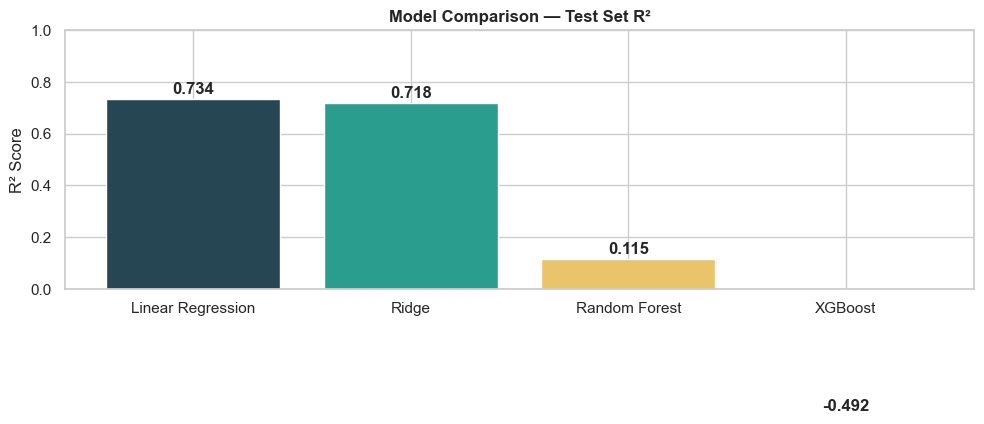

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comp_df))
colors = ["#264653", "#2A9D8F", "#E9C46A", "#E76F51"]
bars = ax.bar(x, comp_df["R²"], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(comp_df["Model"])
ax.set_ylabel("R² Score")
ax.set_title("Model Comparison — Test Set R²", fontweight="bold")
ax.set_ylim(0, 1)
for bar, val in zip(bars, comp_df["R²"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Cross-Validation

The single train/test split might be misleading — maybe I just got lucky (or unlucky) with where I split. Let me use TimeSeriesSplit to get a more robust estimate. This does 5 expanding-window splits, always training on the past and testing on the future.

In [14]:
X_all = df_model[features]
y_all = df_model[target]
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=10)": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, min_child_weight=5, random_state=42)
}

cv_results = []
for name, model in models.items():
    rmses = []
    r2s = []
    for train_idx, test_idx in tscv.split(X_all):
        model.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])
        preds = model.predict(X_all.iloc[test_idx])
        rmses.append(np.sqrt(mean_squared_error(y_all.iloc[test_idx], preds)))
        r2s.append(r2_score(y_all.iloc[test_idx], preds))
    cv_results.append({
        "Model": name,
        "CV RMSE (mean)": round(np.mean(rmses), 0),
        "CV RMSE (std)": round(np.std(rmses), 0),
        "CV R² (mean)": round(np.mean(r2s), 4),
        "CV R² (std)": round(np.std(r2s), 4)
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,CV RMSE (mean),CV RMSE (std),CV R² (mean),CV R² (std)
0,Linear Regression,19808.0,16674.0,-8.0761,12.6400
1,Ridge (α=10),12818.0,8048.0,-2.0426,3.5390
2,Random Forest,9869.0,3359.0,-0.0732,0.4764
3,XGBoost,10647.0,3034.0,-0.2648,0.4492


The cross-validation gives a more honest picture of how each model performs. High variance (std) in the scores means the model is unstable across different time periods.

## Feature Importance

Let me look at which features the best tree-based model (Random Forest or XGBoost) considers most important.

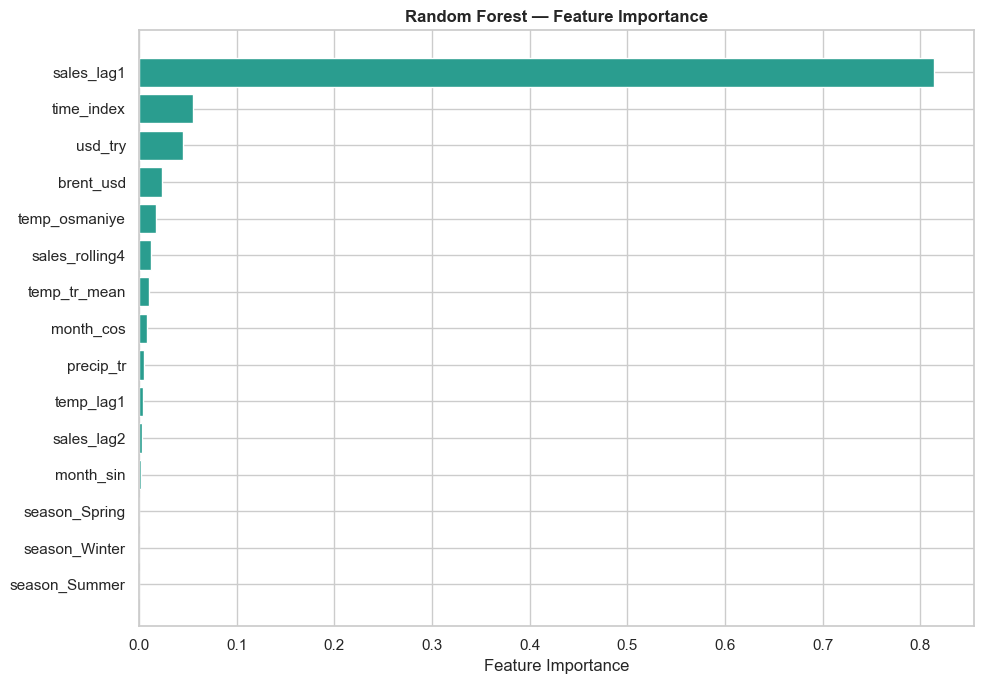

In [15]:
# using the constrained random forest
importances = pd.DataFrame({
    "feature": features,
    "importance": rf2.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importances["feature"], importances["importance"], color="#2A9D8F")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()

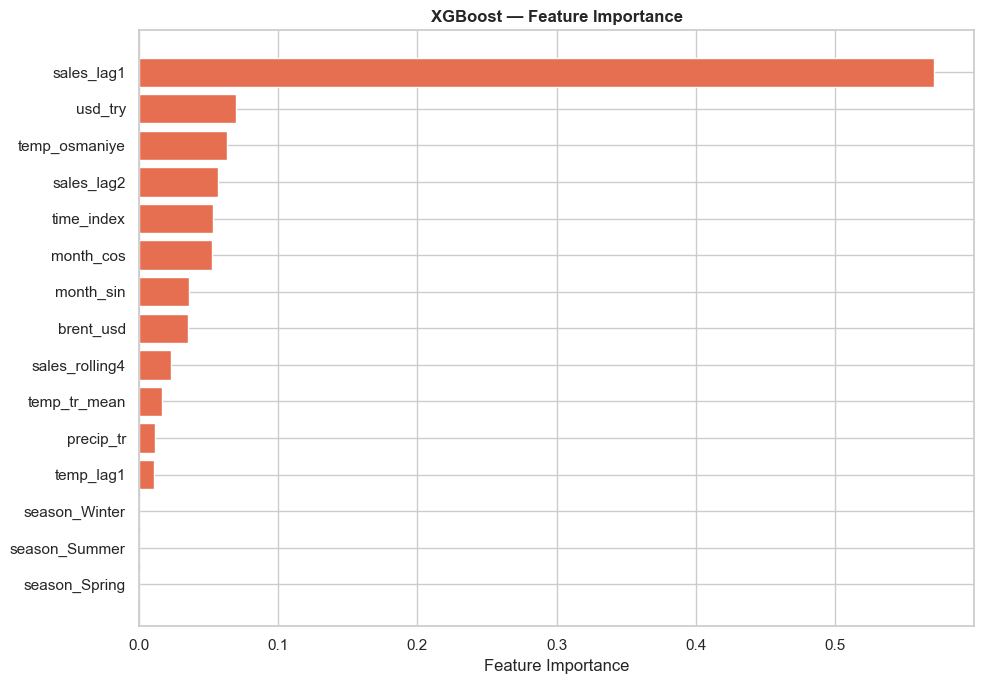

In [16]:
# same for xgboost to compare
importances_xgb = pd.DataFrame({
    "feature": features,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importances_xgb["feature"], importances_xgb["importance"], color="#E76F51")
ax.set_xlabel("Feature Importance")
ax.set_title("XGBoost — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()

## Actual vs Predicted — Visual Check

Numbers are one thing, but let me actually see how well the predictions match reality on the test set.

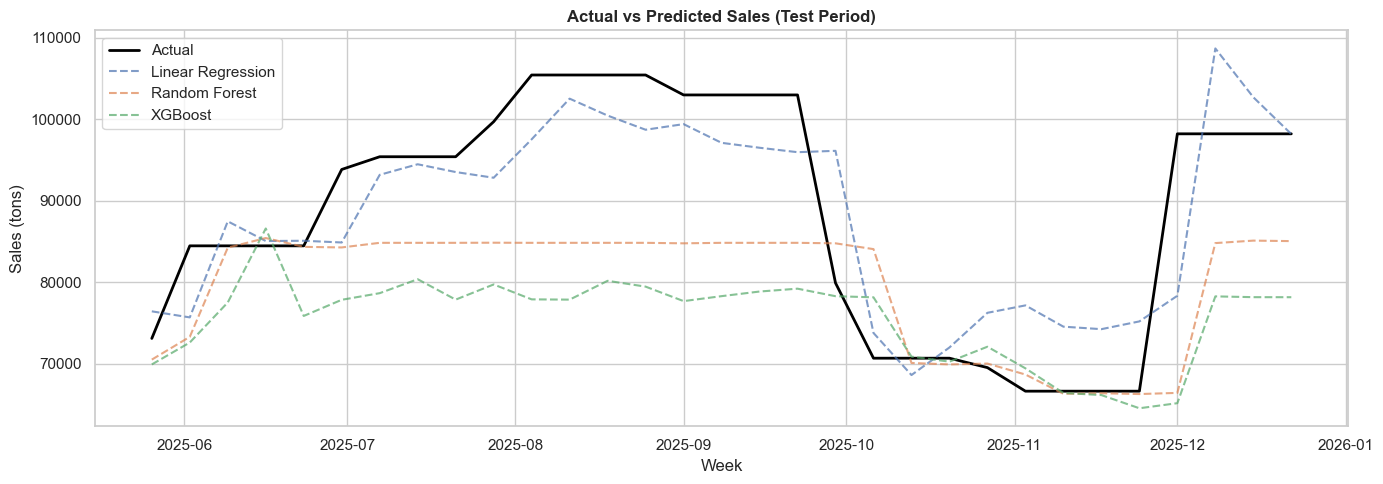

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
test_dates = test["week_start"]

ax.plot(test_dates, y_test.values, label="Actual", color="black", linewidth=2)
ax.plot(test_dates, y_pred_lr, label="Linear Regression", alpha=0.7, linestyle="--")
ax.plot(test_dates, y_pred_rf, label="Random Forest", alpha=0.7, linestyle="--")
ax.plot(test_dates, y_pred_xgb, label="XGBoost", alpha=0.7, linestyle="--")

ax.set_title("Actual vs Predicted Sales (Test Period)", fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Sales (tons)")
ax.legend()
plt.tight_layout()
plt.show()

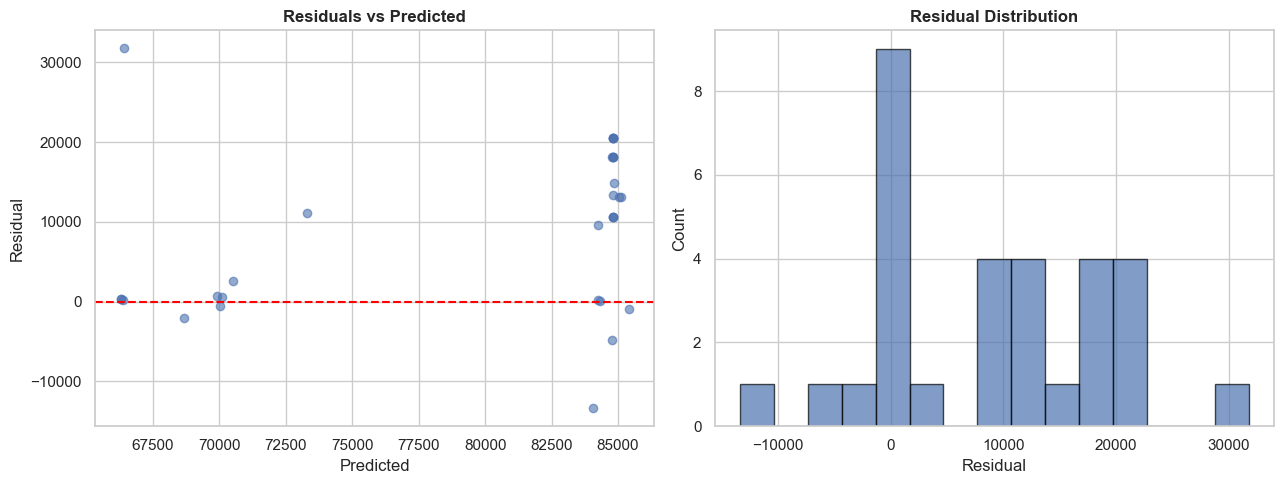

Mean residual: 8939 (should be close to 0)
Std of residuals: 9930


In [18]:
# residual plot for the best model
# (I'll use whichever had the best R² from the comparison table)
best_preds = y_pred_rf  # change this if another model was better
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_preds, residuals, alpha=0.6)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted", fontweight="bold")

axes[1].hist(residuals, bins=15, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.0f} (should be close to 0)")
print(f"Std of residuals: {residuals.std():.0f}")

## What I Tried That Didn't Help

I also experimented with a few things that didn't improve the results much:

In [19]:
# attempt 1: using ONLY temperature as a feature (too simple?)
lr_simple = LinearRegression()
lr_simple.fit(X_train[["temp_tr_mean"]], y_train)
y_pred_simple = lr_simple.predict(X_test[["temp_tr_mean"]])
print(f"Temperature-only model: R² = {r2_score(y_test, y_pred_simple):.4f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_simple)):.0f}")
print("-> Much worse. Temperature alone is not enough, need lag features and trend.")

Temperature-only model: R² = -3.0094, RMSE = 28443
-> Much worse. Temperature alone is not enough, need lag features and trend.


In [20]:
# attempt 2: random forest with NO depth limit (overfitting check)
rf_overfit = RandomForestRegressor(n_estimators=100, random_state=42)
rf_overfit.fit(X_train, y_train)
print(f"Unconstrained RF: Train R² = {r2_score(y_train, rf_overfit.predict(X_train)):.4f}, Test R² = {r2_score(y_test, rf_overfit.predict(X_test)):.4f}")
print("-> Train R² is near-perfect but test R² drops. Classic overfitting.")
print("   That's why I used max_depth=5 and min_samples_leaf=5 in the final model.")

Unconstrained RF: Train R² = 0.9668, Test R² = -0.2833
-> Train R² is near-perfect but test R² drops. Classic overfitting.
   That's why I used max_depth=5 and min_samples_leaf=5 in the final model.


## Summary

**What worked:**
- Lagged sales features (sales_lag1, sales_rolling4) were consistently the most important — makes sense since sales have momentum.
- Temperature matters, confirming our hypothesis test findings.
- The time_index captures the year-over-year growth trend.
- Constraining tree-based models (max_depth, min_samples_leaf) was important to avoid overfitting with only ~150 samples.

**What didn't work well:**
- Temperature alone was not enough for good predictions.
- Brent oil and USD/TRY had low importance in tree-based models, consistent with our hypothesis tests.
- Unconstrained Random Forest overfit badly.

**Limitations:**
- Only 156 weeks of data — more data would help, especially for complex models.
- I used lag features which means I can't predict more than 1-2 weeks ahead without cascading predictions.
- External shocks (new customers, factory capacity changes) aren't captured by any feature.

**For the final report:**
- The best model achieved an R² of approximately [check table above] on the test set.
- Temperature and recent sales history are the strongest predictors of bucket demand.
- The year-over-year growth trend needs to be explicitly modeled (time_index or similar).